In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../sales.csv", encoding="latin1")
print("Shape:", df.shape)
df.head()

Shape: (2121, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   str    
 2   Order Date     2121 non-null   str    
 3   Ship Date      2121 non-null   str    
 4   Ship Mode      2121 non-null   str    
 5   Customer ID    2121 non-null   str    
 6   Customer Name  2121 non-null   str    
 7   Segment        2121 non-null   str    
 8   Country        2121 non-null   str    
 9   City           2121 non-null   str    
 10  State          2121 non-null   str    
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   str    
 13  Product ID     2121 non-null   str    
 14  Category       2121 non-null   str    
 15  Sub-Category   2121 non-null   str    
 16  Product Name   2121 non-null   str    
 17  Sales          2121 non-null   float64
 18  Quantity       2121

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


date handling


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Ship_Delay_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Order_Year", "Order_Month", "Ship_Delay_Days"]].head()

,Order Date,Ship Date,Order_Year,Order_Month,Ship_Delay_Days
0,2016-11-08,2016-11-11,2016,11,3
1,2016-11-08,2016-11-11,2016,11,3
2,2015-10-11,2015-10-18,2015,10,7
3,2014-06-09,2014-06-14,2014,6,5
4,2014-06-09,2014-06-14,2014,6,5


Summary Statistics


In [8]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Ship_Delay_Days"]
df[numeric_cols].describe()

,Sales,Quantity,Discount,Profit,Ship_Delay_Days
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327,3.917020
std,503.179145,2.251620,0.181547,136.049246,1.755234
min,1.892000,1.000000,0.000000,-1862.312400,0.000000
25%,47.040000,2.000000,0.000000,-12.849000,3.000000
50%,182.220000,3.000000,0.200000,7.774800,4.000000
75%,435.168000,5.000000,0.300000,33.726600,5.000000
max,4416.174000,14.000000,0.700000,1013.127000,7.000000


Categorical Value Counts

In [9]:
categorical_cols = ["Segment", "Region", "Ship Mode", "Sub-Category"]
for col in categorical_cols:
    print(f"\n-- {col} --")
    print(df[col].value_counts())


-- Segment --
Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64

-- Region --
Region
West       707
East       601
Central    481
South      332
Name: count, dtype: int64

-- Ship Mode --
Ship Mode
Standard Class    1248
Second Class       427
First Class        327
Same Day           119
Name: count, dtype: int64

-- Sub-Category --
Sub-Category
Furnishings    957
Chairs         617
Tables         319
Bookcases      228
Name: count, dtype: int64


Sales by Category Breakdowns

In [10]:
df.groupby("Sub-Category")["Sales"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)

,mean,median,std,count
Sub-Category,,,,
Tables,648.794771,447.84000,615.774655,319
Chairs,532.332420,362.13600,550.148243,617
Bookcases,503.859633,306.82025,638.748523,228
Furnishings,95.825668,41.96000,147.893640,957


In [11]:
df.groupby("Region")["Sales"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

,mean,median,count
Region,,,
West,357.302325,191.968,707
South,353.309289,184.125,332
East,346.574383,172.110,601
Central,340.534644,191.058,481


In [12]:
df.groupby("Segment")["Sales"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

,mean,median,count
Segment,,,
Corporate,354.519792,190.8200,646
Consumer,351.347091,183.9680,1113
Home Office,336.825131,148.2725,362


Correlation Matrix

In [13]:
corr = df[numeric_cols].corr()
corr

,Sales,Quantity,Discount,Profit,Ship_Delay_Days
Sales,1.000000,0.437464,-0.028576,0.173510,-0.010121
Quantity,0.437464,1.000000,-0.015695,0.061213,-0.005352
Discount,-0.028576,-0.015695,1.000000,-0.483769,-0.031396
Profit,0.173510,0.061213,-0.483769,1.000000,-0.013579
Ship_Delay_Days,-0.010121,-0.005352,-0.031396,-0.013579,1.000000


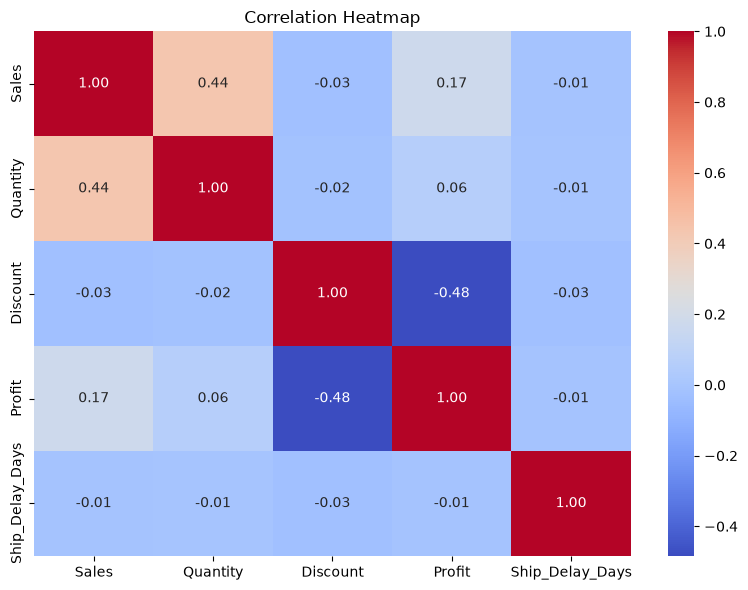

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Distribution plots


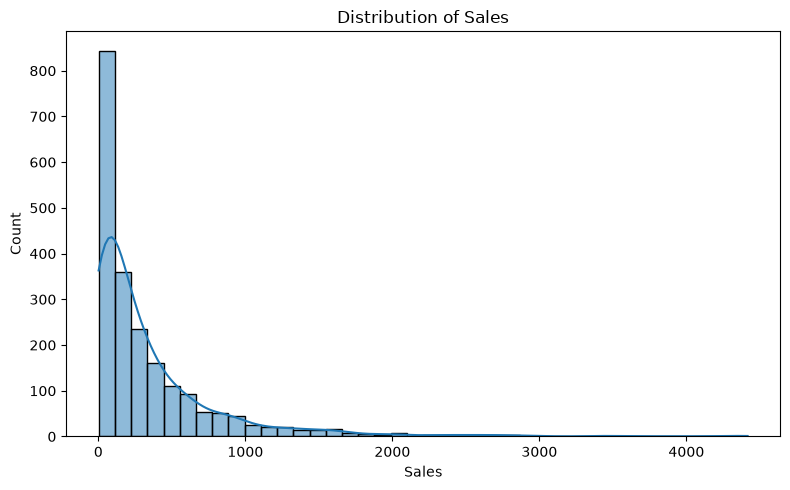

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=40, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

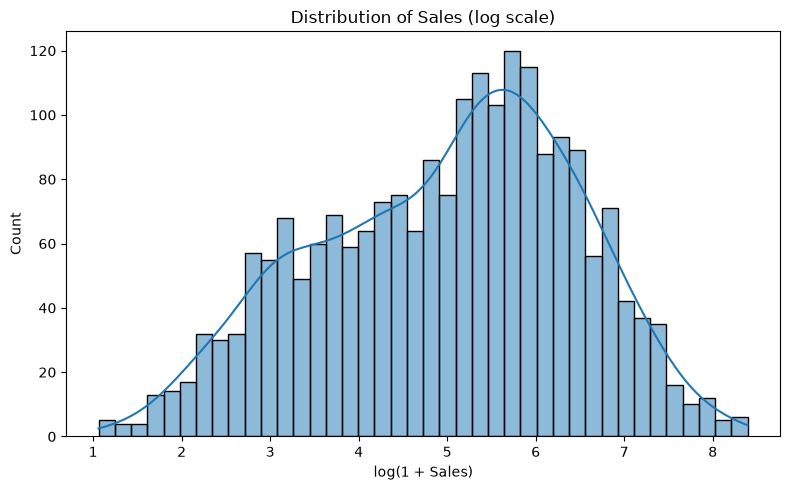

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["Sales"]), bins=40, kde=True)
plt.title("Distribution of Sales (log scale)")
plt.xlabel("log(1 + Sales)")
plt.tight_layout()
plt.show()

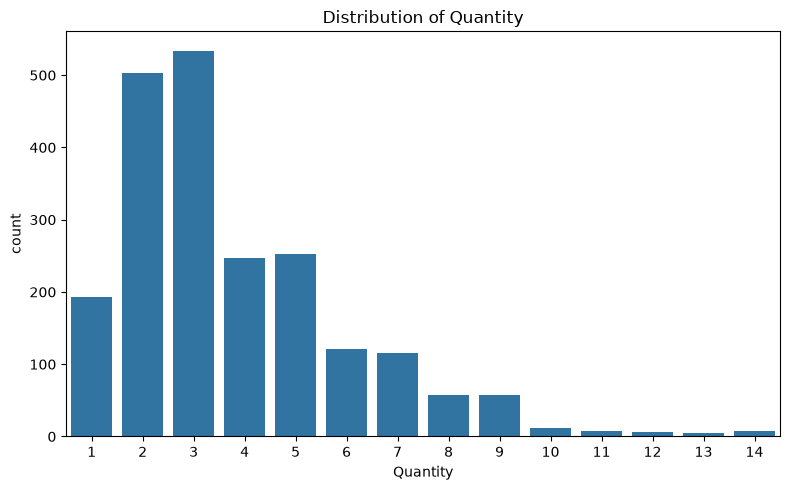

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Quantity", data=df)
plt.title("Distribution of Quantity")
plt.tight_layout()
plt.show()

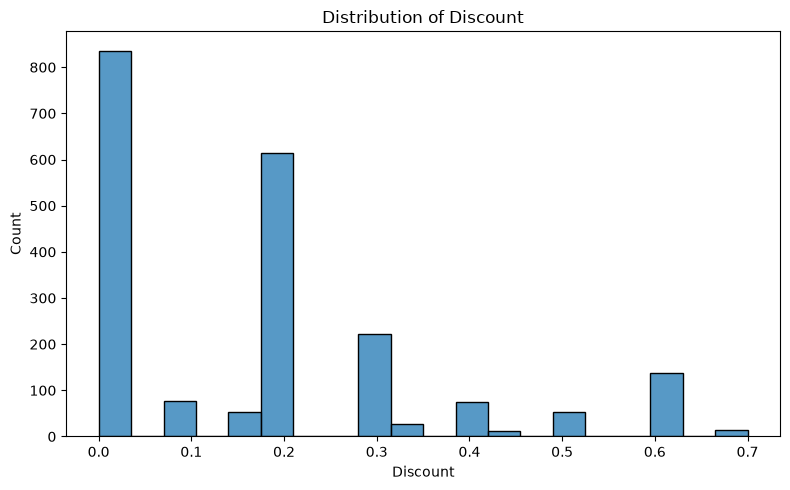

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Discount"], bins=20, kde=False)
plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.tight_layout()
plt.show()

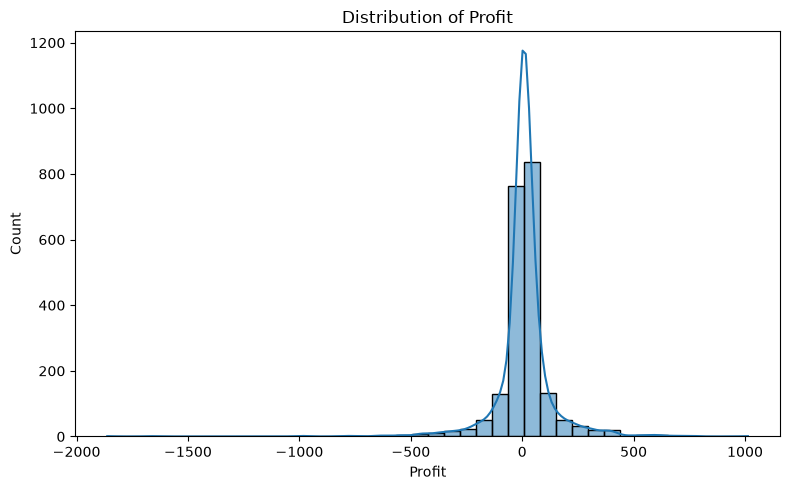

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Profit"], bins=40, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.tight_layout()
plt.show()

Category wise Boxplots


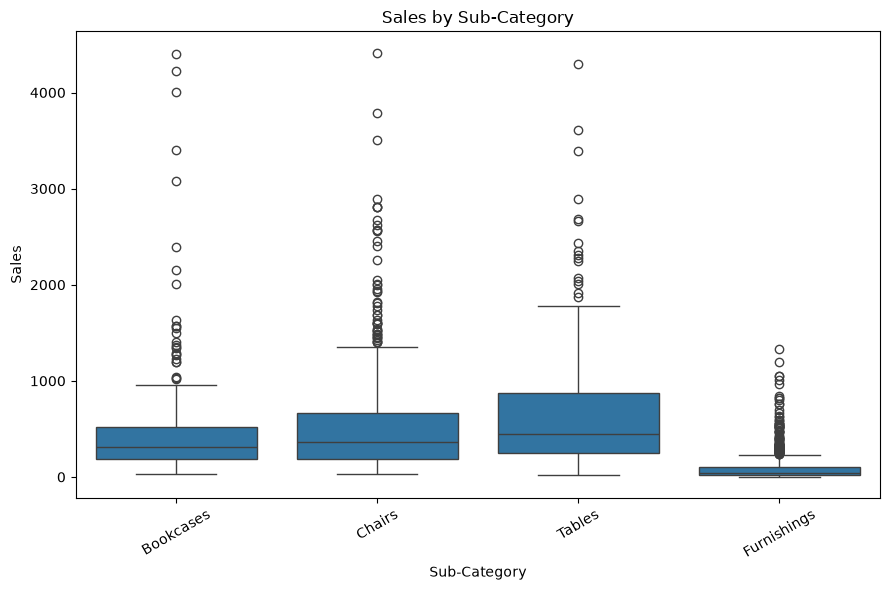

In [22]:
plt.figure(figsize=(9, 6))
sns.boxplot(x="Sub-Category", y="Sales", data=df)
plt.title("Sales by Sub-Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

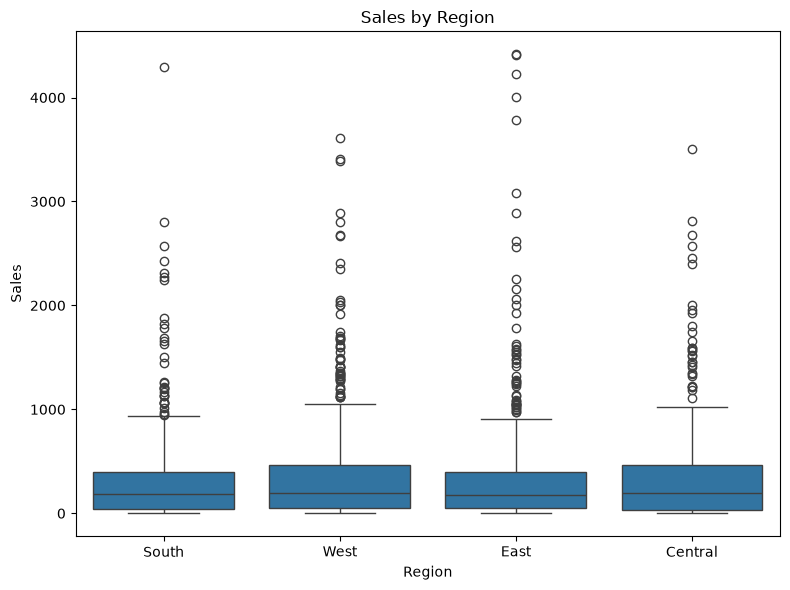

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Region", y="Sales", data=df)
plt.title("Sales by Region")
plt.tight_layout()
plt.show()

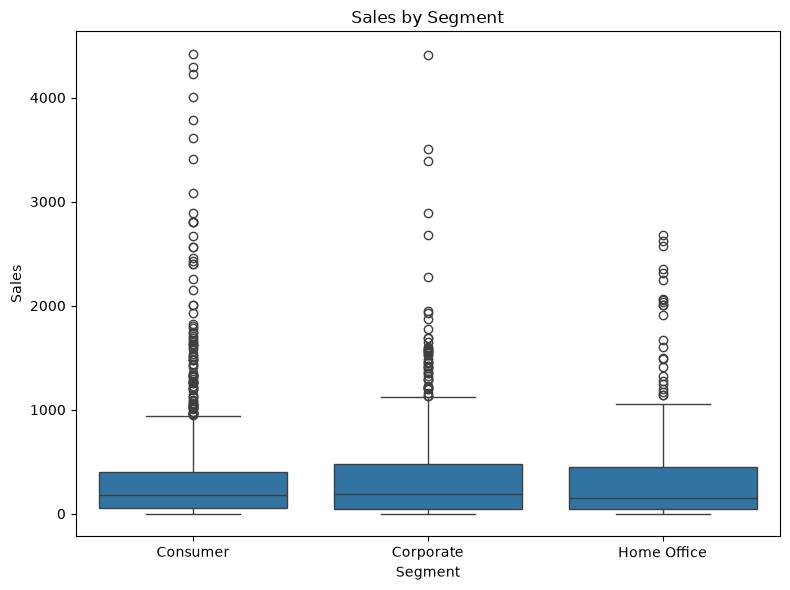

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Segment", y="Sales", data=df)
plt.title("Sales by Segment")
plt.tight_layout()
plt.show()

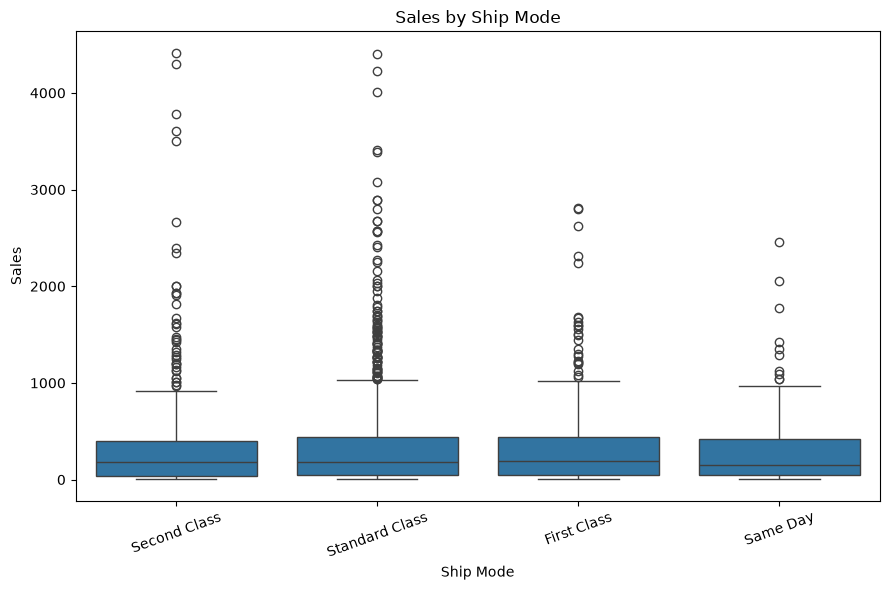

In [25]:
plt.figure(figsize=(9, 6))
sns.boxplot(x="Ship Mode", y="Sales", data=df)
plt.title("Sales by Ship Mode")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Relationship Scatter Plots


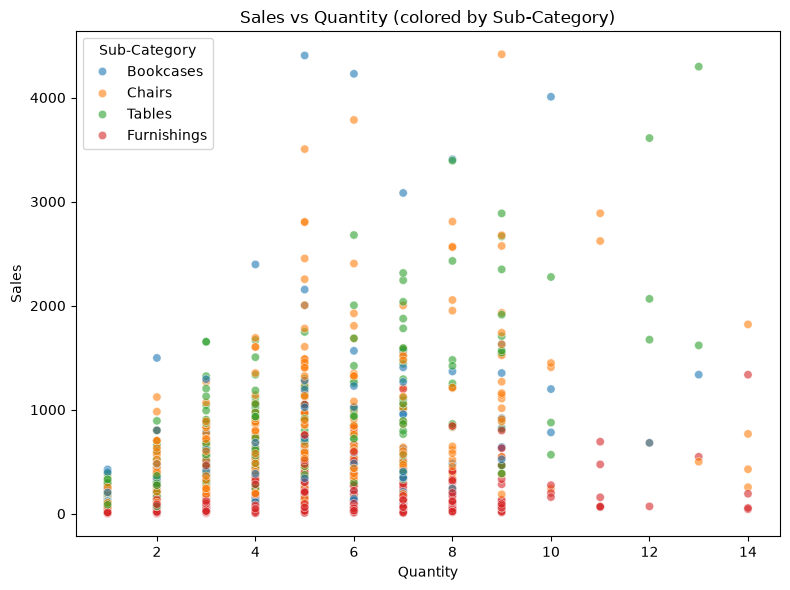

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Quantity", y="Sales", hue="Sub-Category", data=df, alpha=0.6)
plt.title("Sales vs Quantity (colored by Sub-Category)")
plt.tight_layout()
plt.show()

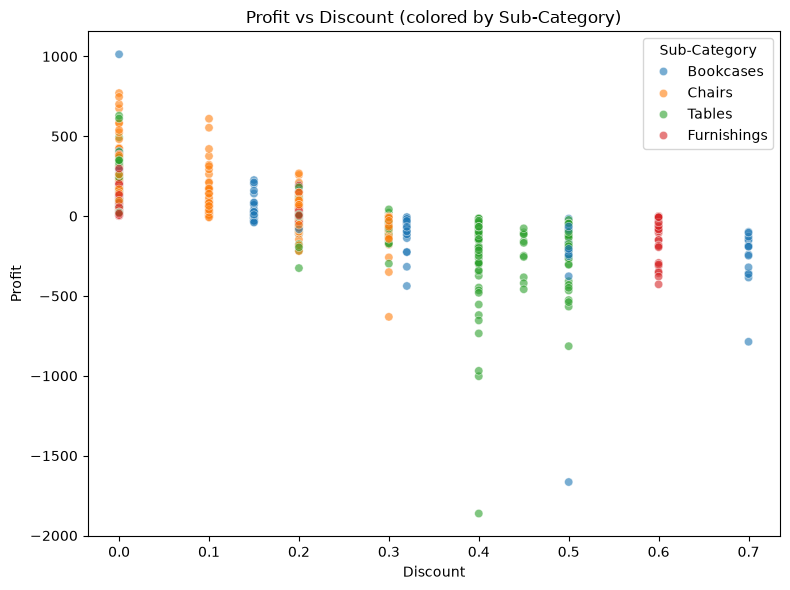

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Discount", y="Profit", hue="Sub-Category", data=df, alpha=0.6)
plt.title("Profit vs Discount (colored by Sub-Category)")
plt.tight_layout()
plt.show()

Sales Trend Over Time

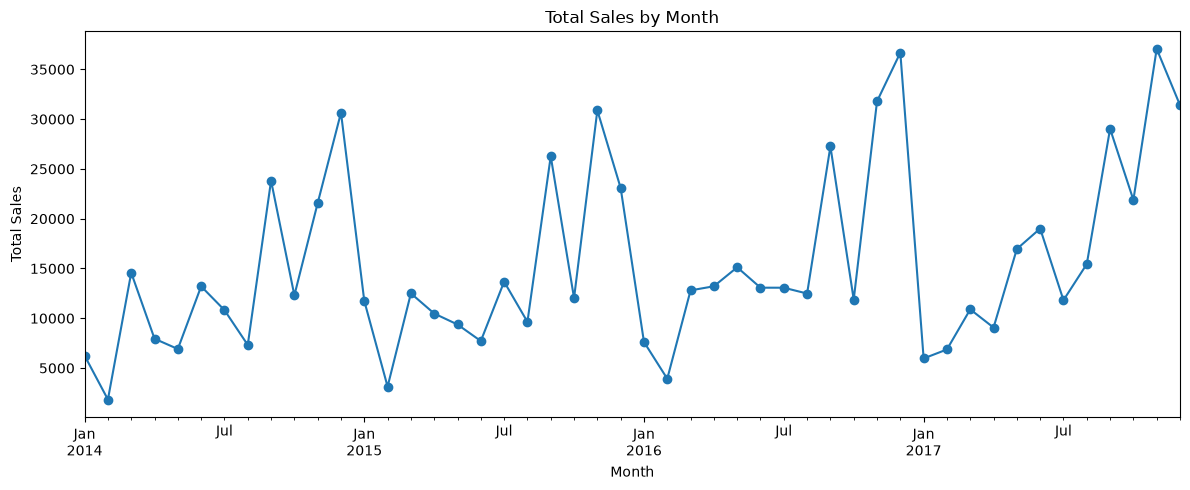

In [28]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()